In [3]:
!pip show torch

Name: torch
Version: 2.7.1+cu118
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu11, nvidia-cuda-cupti-cu11, nvidia-cuda-nvrtc-cu11, nvidia-cuda-runtime-cu11, nvidia-cudnn-cu11, nvidia-cufft-cu11, nvidia-curand-cu11, nvidia-cusolver-cu11, nvidia-cusparse-cu11, nvidia-nccl-cu11, nvidia-nvtx-cu11, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision


### WARNING : paddlepaddle-gpu==3.2.2 ne peut pas être utilisé en même temps que pytorch car il n'y a pas de version de pytorch (https://github.com/pytorch/pytorch/blob/main/RELEASE.md#release-compatibility-matrix) qui ait ses dépendances compatibles avec celles de paddlepaddle-gpu==3.2.2 (en particulier CUDNN et NCCL rentre en conflit car soit pytorch a besoin de version trop récentes, soit trop anciennes). Il faut donc réinstaller pytorch pour qu'il réinstalle les bonnes versions de ses dépendances après avoir installé paddlepaddle-gpu==3.2.2 qui les a écrasées pour avoir les bonnes versions pour lui.

In [6]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.6/839.6 MB ? eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 115.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 768.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 MB 6.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nccl-cu11
    Found existing installation: nvidia-nccl-cu11 2.19.3
    Uninstalling nvidia-nccl-cu11-2.19.3:
      Successfully uninstalled nvidia-nccl-cu11-2.19.3
  Attempting uninstall: nvidia-cudnn-cu11
    Found existing installation: nvidia-cudnn-cu11 8.9.6.50
    Uninstalling nvidia-cudnn-cu11-8.9.6.50:
      Successfully uninstalled nvidia-cudnn-cu11-8.9.6.50
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the fol

In [7]:
!pip uninstall -y paddlepaddle-gpu paddleocr langchain
!pip install paddlepaddle-gpu==3.2.2 -i https://www.paddlepaddle.org.cn/packages/stable/cu118/
!pip install "paddleocr>3.0.0"

Found existing installation: paddlepaddle-gpu 3.2.2
Uninstalling paddlepaddle-gpu-3.2.2:
  Successfully uninstalled paddlepaddle-gpu-3.2.2
Found existing installation: paddleocr 3.3.2
Uninstalling paddleocr-3.3.2:
  Successfully uninstalled paddleocr-3.3.2
Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu118/
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu118/paddlepaddle-gpu/paddlepaddle_gpu-3.2.2-cp312-cp312-linux_x86_64.whl (1071.6 MB)
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu118/nvidia-cudnn-cu11/nvidia_cudnn_cu11-8.9.6.50-py3-none-manylinux1_x86_64.whl (699.9 MB)
  Using cached https://paddle-whl.bj.bcebos.com/stable/cu118/nvidia-nccl-cu11/nvidia_nccl_cu11-2.19.3-py3-none-manylinux1_x86_64.whl (135.3 MB)
  Attempting uninstall: nvidia-nccl-cu11
    Found existing installation: nvidia-nccl-cu11 2.20.5
    Uninstalling nvidia-nccl-cu11-2.20.5:
      Successfully uninstalled nvidia-nccl-cu11-2.20.5
  Attempting uninstall: nvidia-cudnn-cu

In [8]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import glob
import pickle
from paddleocr import PaddleOCR
from tqdm import tqdm

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


## Test de PaddleOCR sur une image

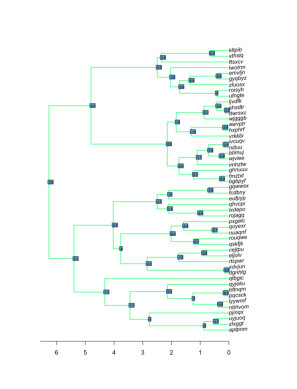

In [ ]:
img_path = "dev/_datasets/Tree_PNG_50tips_NOISE_1/images/Tree_50_1.png"
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
ocr = PaddleOCR(lang="en", use_doc_unwarping=False, ocr_version="PP-OCRv5")
results = ocr.predict(image)

Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dorian\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dorian\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\dorian\.paddlex\official_models\en_PP-OCRv5_mobile_rec`.


![PP-OCRv5 image](attachment:image.png)

In [ ]:
print(result[0])

{'input_path': None, 'page_index': None, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'input_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[255, ..., 255],
        ...,
        [255, ..., 255]]], shape=(2000, 1500, 3), dtype=uint8), 'model_settings': {'use_doc_orientation_classify': True, 'use_doc_unwarping': True}, 'angle': 180, 'rot_img': array([[[  0, ...,   0],
        ...,
        [  0, ...,   0]],

       ...,

       [[  0, ...,   0],
        ...,
        [255, ..., 255]]], shape=(2000, 1500, 3), dtype=uint8), 'output_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[255, ..., 255],
        ...,
        [255, ..., 255]]], shape=(2000, 1500, 3), dtype=uint8)}, 'dt_polys': [array([[653,  34],
       ...,
       [653,  80]], shape=(4, 2), dtype=int16), array([[840,  31],
       ...,
       [840,  79]], shape=(4, 2), dtype=int16), array([[1017,   33],
       ...,
       [1017

In [ ]:
for res in result:
    res.save_to_img("dev/_notebooks/label_extraction_paddleocr_outputs")

In [ ]:
outputs = []

for line in results:
    rec_polys = line.get("rec_polys")
    rec_boxes = line.get("rec_boxes")
    rec_texts = line.get("rec_texts")
    rec_scores = line.get("rec_scores")

    for i, poly in enumerate(rec_polys):
        outputs.append({
            "polygon": rec_polys[i],
            "bbox": rec_boxes[i],
            "text": rec_texts[i],
            "score": rec_scores[i]
        })

In [ ]:
print(outputs)

[{'polygon': array([[1175,  202],
       ...,
       [1177,  241]], shape=(4, 2), dtype=int16), 'bbox': array([1175, ...,  241], shape=(4,), dtype=int16), 'text': 'kltpib', 'score': 0.9328272938728333}, {'polygon': array([[1072,  224],
       ...,
       [1072,  253]], shape=(4, 2), dtype=int16), 'bbox': array([1072, ...,  253], shape=(4,), dtype=int16), 'text': '6.3', 'score': 0.9973090291023254}, {'polygon': array([[1175,  233],
       ...,
       [1177,  272]], shape=(4, 2), dtype=int16), 'bbox': array([1175, ...,  272], shape=(4,), dtype=int16), 'text': 'xthslq', 'score': 0.994307816028595}, {'polygon': array([[808, 246],
       ...,
       [808, 276]], shape=(4, 2), dtype=int16), 'bbox': array([808, ..., 276], shape=(4,), dtype=int16), 'text': '2.9', 'score': 0.8663812279701233}, {'polygon': array([[1176,  269],
       ...,
       [1178,  302]], shape=(4, 2), dtype=int16), 'bbox': array([1176, ...,  302], shape=(4,), dtype=int16), 'text': 'ftsxcv', 'score': 0.9887886643409729}, {'

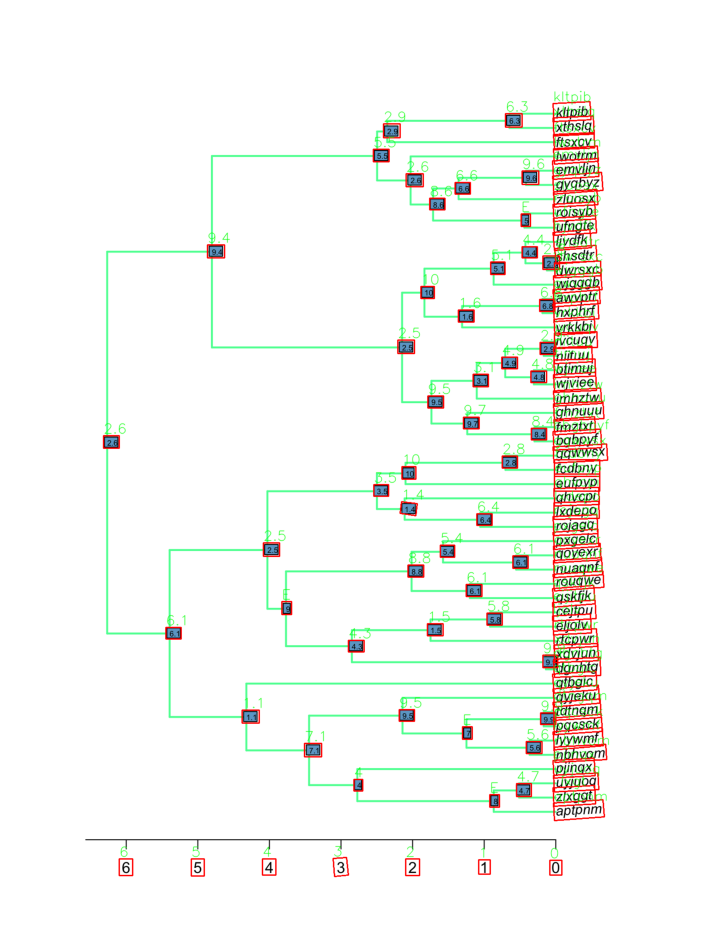

In [ ]:
plt.figure(figsize=(12, 12))
img_show = image.copy()
for item in outputs:
    poly = np.array(item["polygon"], dtype=np.int32)

    #poly[:, 0] = img_show.shape[1] - poly[:, 0]
    #poly[:, 1] = img_show.shape[0] - poly[:, 1]

    text = item["text"]
    cv2.polylines(img_show, [poly], True, (255, 0, 0), 2)
    x, y = poly[0]
    cv2.putText(img_show, text, (int(x), int(y) - 5), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 1, cv2.LINE_AA)
plt.imshow(img_show)
plt.axis("off")
plt.show()

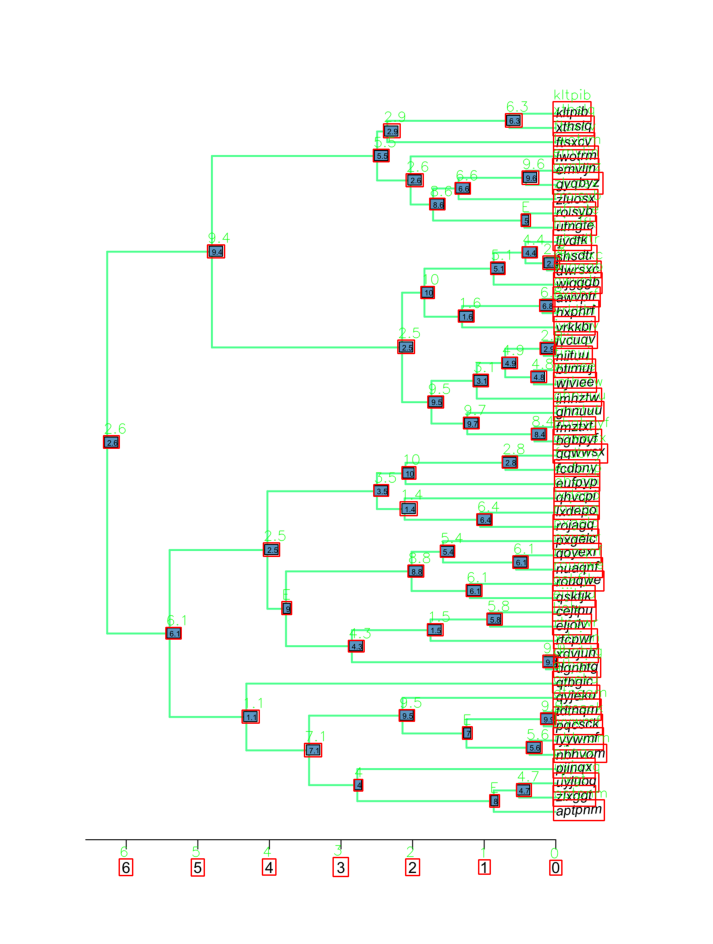

In [ ]:
plt.figure(figsize=(12, 12))
img_show = image.copy()
for item in outputs:
    x1, y1, x2, y2 = item["bbox"]; text = item["text"]

    #x1, x2 = img_show.shape[1] - x1, img_show.shape[1] - x2
    #y1, y2 = img_show.shape[0] - y1, img_show.shape[0] - y2

    cv2.rectangle(img_show, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(img_show, text, (x1, max(y1 - 5, 10)), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 1, cv2.LINE_AA)
plt.imshow(img_show)
plt.axis("off")
plt.show()

In [ ]:
filtered_text_boxes = [
    item
    for item in outputs
    if not any(char.isdigit() for char in item["text"])
]

for i, entry in enumerate(filtered_text_boxes[:20], 1):
    print(f"{i}: text='{entry['text']}', score={entry['score']:.2f}, bbox={entry['bbox']}")

1: text='kltpib', score=0.93, bbox=[1175 ...  241]
2: text='xthslq', score=0.99, bbox=[1175 ...  272]
3: text='ftsxcv', score=0.99, bbox=[1176 ...  302]
4: text='Iwotrm', score=0.96, bbox=[1176 ...  333]
5: text='emvljn', score=0.82, bbox=[1174 ...  366]
6: text='gyqbyz', score=1.00, bbox=[1174 ...  398]
7: text='zluosx', score=1.00, bbox=[1176 ...  426]
8: text='rroisyb', score=0.92, bbox=[1175 ...  457]
9: text='E', score=0.90, bbox=[1106 ...  468]
10: text='ufngte', score=1.00, bbox=[1176 ...  487]
11: text='hjvdfk', score=0.74, bbox=[1175 ...  520]
12: text='shsdtr', score=1.00, bbox=[1179 ...  549]
13: text='dwrsxc', score=1.00, bbox=[1178 ...  579]
14: text='wjgggb', score=0.97, bbox=[1176 ...  613]
15: text='awvptr', score=0.83, bbox=[1175 ...  642]
16: text='hxphrf', score=0.95, bbox=[1175 ...  674]
17: text='vrkkbi', score=1.00, bbox=[1177 ...  703]
18: text='ivcuqv', score=0.99, bbox=[1178 ...  732]
19: text='niituu', score=1.00, bbox=[1176 ...  765]
20: text='timuj', score=0

## OCR sur un ensemble d'images

In [9]:
ocr = PaddleOCR(lang="en", use_doc_unwarping=False, ocr_version="PP-OCRv5")

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but s

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

config.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

...

.gitattributes: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

inference.json: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

inference.pdiparams:   0%|          | 0.00/7.77M [00:00<?, ?B/s]

In [10]:
image_folder = "images/"
image_paths = glob.glob(os.path.join(image_folder, "*.png"))

#image_paths = image_paths[:2]
print(len(image_paths))

1000


In [11]:
all_results = []

for img_path in tqdm(image_paths, desc="OCR images"):
    results = ocr.predict(img_path)
    all_results.extend(results)

print(f"OCR effectué sur {len(image_paths)} images.")

OCR images:   9%|▉         | 92/1000 [01:35<15:45,  1.04s/it]


KeyboardInterrupt: 

In [ ]:
with open("ocr_all_results.pkl", "wb") as f:
    pickle.dump(all_results, f)

In [ ]:
with open("ocr_all_results.pkl", "rb") as f:
    all_results = pickle.load(f)

In [ ]:
outputs = []

for result in all_results:
    input_path = result.get("input_path")
    input_img = cv2.cvtColor(cv2.imread(input_path), cv2.COLOR_BGR2RGB)

    rec_polys = result.get("rec_polys")
    rec_boxes = result.get("rec_boxes")
    rec_texts = result.get("rec_texts")
    rec_scores = result.get("rec_scores")

    for i in range(len(rec_polys)):
        outputs.append({
            "input_path": input_path,
            "input_img": input_img,
            "polygon": rec_polys[i],
            "bbox": rec_boxes[i],
            "text": rec_texts[i],
            "score": rec_scores[i]
        })

print(f"Nombre total de textes détectés : {len(outputs)}")

Nombre total de textes détectés : 202


{'input_path': 'dev/_datasets/Tree_PNG_50tips_NOISE_1/images\\Tree_50_1.png', 'input_img': array([[[255, ..., 255],
        ...,
        [255, ..., 255]],

       ...,

       [[255, ..., 255],
        ...,
        [255, ..., 255]]], shape=(2000, 1500, 3), dtype=uint8), 'polygon': array([[1175,  202],
       ...,
       [1177,  241]], shape=(4, 2), dtype=int16), 'bbox': array([1175, ...,  241], shape=(4,), dtype=int16), 'text': 'kltpib', 'score': 0.9257287979125977}


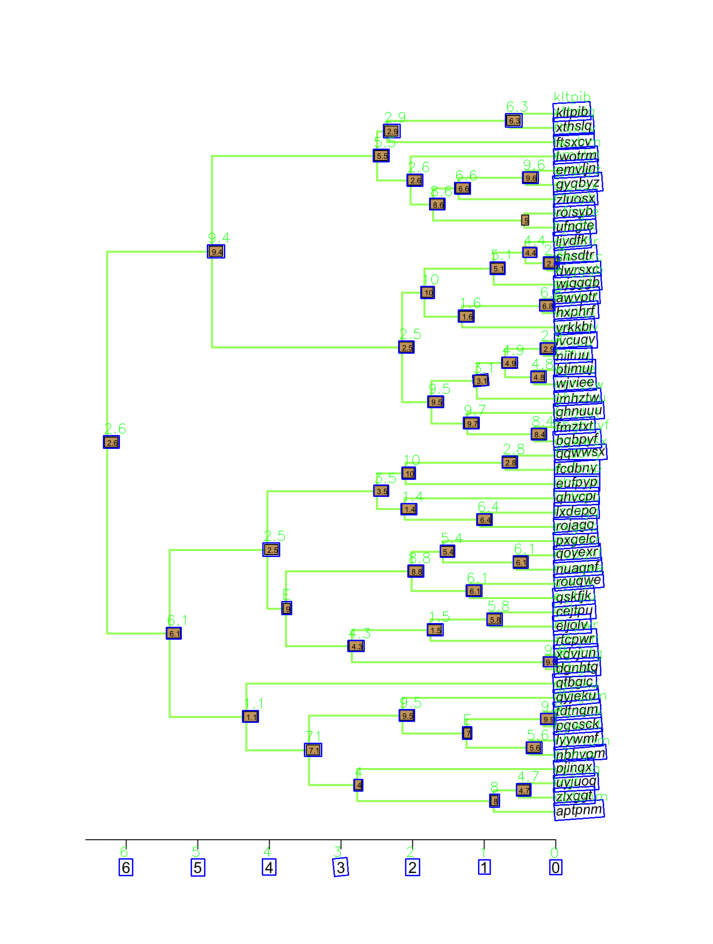

In [ ]:
img_path = "Tree_50_1.png"
img_outputs = [item for item in outputs if img_path in os.path.basename(item["input_path"])]

if not img_outputs:
    print(f"Aucun texte trouvé pour {img_path}")
else:
    print(img_outputs[0])
    img_show = img_outputs[0]["input_img"].copy()

    plt.figure(figsize=(12, 12))
    for item in img_outputs:
        poly = np.array(item["polygon"], dtype=np.int32)
        text = item["text"]
        cv2.polylines(img_show, [poly], isClosed=True, color=(255, 0, 0), thickness=2)
        x, y = poly[0]
        cv2.putText(img_show, text, (int(x), int(y) - 5), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 1, cv2.LINE_AA)
    plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

## Labelling

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import csv
import re
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

In [ ]:
class PhyloLabelClassifier(nn.Module):
    def __init__(self, geo_feat_dim: int):
        super().__init__()

        # Backbone pour image globale
        self.global_cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.global_cnn.fc = nn.Identity() # sortie: 512, on utilise ResNet comme extracteur de features, pas comme classifieur

        # Backbone pour crop texte
        self.crop_cnn = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.crop_cnn.fc = nn.Identity() # sortie: 512

        # Projection des features géométriques
        self.geo_fc = nn.Sequential(
            nn.Linear(geo_feat_dim, 64),
            nn.ReLU(),
            nn.LayerNorm(64) # sortie: 64
        )

        # MLP de fusion
        self.classifier = nn.Sequential(
            nn.Linear(512 + 512 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1) # binaire
        )

    def forward(self, global_img, crop_img, geo_feats):
        """
        global_img : (B, 3, H, W)
        crop_img   : (B, 3, h, w)
        geo_feats  : (B, geo_feat_dim)
        """

        # Rôle : capturer la structure globale de l'arbre phylogénétique
        global_feat = self.global_cnn(global_img) # (B, 512)

        # Rôle : capturer le contexte local du texte
        crop_feat = self.crop_cnn(crop_img) # (B, 512)

        # Rôle : encoder des informations numériques déjà connues
        geo_feat = self.geo_fc(geo_feats) # (B, 64)

        # Rôle : fusionner toutes les informations
        fused = torch.cat([global_feat, crop_feat, geo_feat], dim=1) # (B, 1088)

        logits = self.classifier(fused) # (B, 1)

        return logits.squeeze(1) # (B, 1) -> (B,) (nécessaire pour être compatible avec BCEWithLogitsLoss)

In [ ]:
class PhyloTextDataset(Dataset):
    """
    Dataset PyTorch des textes détectés.
    Chaque item contient :
    - global_img : image complète
    - crop_img   : crop autour du texte (bbox élargie)
    - geo_feats  : vecteur avec des données géométrique
    - label      : 0 ou 1 (1 si le texte est présent dans les labels de l'arbre)
    """

    def __init__(self, outputs, labels):
        """
        outputs : liste de dictionnaires {input_path, img, polygon, bbox, text, score}
        labels  : dictionnaire {img_name: set(label_texts)}
        """
        self.data = []

        for item in outputs:
            img_base = os.path.basename(item["input_path"])
            img_name = os.path.splitext(img_base)[0]

            # Label = 1 si le texte OCR est dans les labels de l'image
            image_labels = labels.get(img_name, set())
            label = 1 if item["text"] in image_labels else 0

            # Crop autour du texte (bbox)
            crop_img = PhyloTextDataset.get_enlarged_crop(item["input_img"], item["bbox"], scale=4.0)

            # Features géométriques
            geo_feats = PhyloTextDataset.compute_geo_features(item["bbox"], item["input_img"].shape)

            # Ajouter au dataset
            self.data.append({
                "global_img": item["input_img"],
                "crop_img": crop_img,
                "geo_feats": geo_feats,
                "label": label
            })

        print(f"Dataset construit : {len(self.data)} items.")

    def get_enlarged_crop(img, bbox, scale=4):
        """
        img   : image NumPy (H,W,C)
        bbox  : [x_min, y_min, x_max, y_max]
        scale : facteur d'agrandissement

        Retourne un crop élargi, sans dépasser l'image.
        """
        H, W, _ = img.shape
        x_min, y_min, x_max, y_max = bbox

        # centre du bbox
        x_c = (x_min + x_max) / 2
        y_c = (y_min + y_max) / 2

        # taille originale
        w = x_max - x_min
        h = y_max - y_min

        # nouvelle taille
        new_w = w * scale
        new_h = h * scale

        # nouvelles coordonnées
        x_min_new = int(max(x_c - new_w/2, 0))
        x_max_new = int(min(x_c + new_w/2, W))
        y_min_new = int(max(y_c - new_h/2, 0))
        y_max_new = int(min(y_c + new_h/2, H))

        return img[y_min_new:y_max_new, x_min_new:x_max_new].copy()

    def compute_geo_features(bbox, img_shape):
        """
        Calcule des features géométriques.

        bbox      : [x_min, y_min, x_max, y_max]
        img_shape : tuple (H, W, C) de l'image

        Retoure [x_center, y_center, width, height] normalisés.
        """
        x_min, y_min, x_max, y_max = bbox
        img_h, img_w = img_shape[:2]

        # centre du bbox
        x_center = (x_min + x_max) / 2 / img_w
        y_center = (y_min + y_max) / 2 / img_h

        # taille
        width  = (x_max - x_min) / img_w
        height = (y_max - y_min) / img_h

        return [x_center, y_center, width, height]

    def img_to_tensor(img, size=(1024, 1024)):
        img = cv2.resize(img, size, interpolation=cv2.INTER_LINEAR)
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) / 255.0
        return img

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Normalisation image et conversion en torch tensor (C,H,W)
        global_img = PhyloTextDataset.img_to_tensor(item["global_img"], size=(1024, 1024))
        crop_img   = PhyloTextDataset.img_to_tensor(item["crop_img"], size=(1024, 1024))
        geo_feats  = torch.tensor(item["geo_feats"], dtype=torch.float32)
        label      = torch.tensor(item["label"], dtype=torch.float32)

        return global_img, crop_img, geo_feats, label

In [ ]:
def train_model(model, train_loader, val_loader, device="cpu", epochs=10, lr=1e-4):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    history = {
        "train_loss": [],
        "train_acc": [],
        "train_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": []
    }

    for epoch in range(epochs):
        # Training
        model.train()
        all_preds, all_labels = [], []
        train_loss = 0
        for _, (global_imgs, crop_imgs, geo_feats, labels) in enumerate(tqdm(train_loader, desc="Training")):
            global_imgs = global_imgs.to(device)
            crop_imgs = crop_imgs.to(device)
            geo_feats = geo_feats.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            logits = model(global_imgs, crop_imgs, geo_feats)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(labels)

            preds = (torch.sigmoid(logits) > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        epoch_loss = train_loss / len(train_loader.dataset)
        epoch_acc = accuracy_score(all_labels, all_preds)
        epoch_f1 = f1_score(all_labels, all_preds)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}, F1: {epoch_f1:.4f}")

        history["train_loss"].append(epoch_loss)
        history["train_acc"].append(epoch_acc)
        history["train_f1"].append(epoch_f1)

        # Validation
        model.eval()
        val_preds, val_labels = [], []
        val_loss = 0
        with torch.no_grad():
            for _, (global_imgs, crop_imgs, geo_feats, labels) in enumerate(tqdm(val_loader, desc="Validation")):
                global_imgs = global_imgs.to(device)
                crop_imgs = crop_imgs.to(device)
                geo_feats = geo_feats.to(device)
                labels = labels.to(device)

                logits = model(global_imgs, crop_imgs, geo_feats)
                loss = criterion(logits, labels)
                val_loss += loss.item() * len(labels)

                preds = (torch.sigmoid(logits) > 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds)
        print(f"Val - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        scheduler.step()

    return history

In [ ]:
table_path = "dev/_datasets/Tree_PNG_50tips_NOISE_1/table_tree_newick_50tips_NOISE_1.txt"

labels = {}
with open(table_path, "r") as f:
    reader = csv.reader(f, delimiter=" ")
    for row in reader:
        if len(row) < 3:
            continue
        img_name = row[1].strip('"')
        newick = row[2].strip('"')
        img_labels = set(re.findall(r"([A-Za-z0-9_]+):", newick))
        labels[img_name] = img_labels

print(f"Labels extraits pour {len(labels)} images.")

Labels extraits pour 1000 images.


In [ ]:
print(labels["Tree_50_1"])

{'ivcuqv', 'qyjeku', 'cejtpu', 'imhztw', 'shsdtr', 'pqcsck', 'dgnhtg', 'emvljn', 'nbhvom', 'qtbgic', 'rouqwe', 'bgbpyf', 'xthslq', 'qhvcpi', 'fcdbny', 'qskfjk', 'kltpib', 'zlxggt', 'ftsxcv', 'btimuj', 'ufngte', 'dwrsxc', 'rtcpwr', 'ljvdfk', 'lwotrm', 'fmztxt', 'vrkkbi', 'uyjuoq', 'pjinqx', 'ghnuuu', 'wjgggb', 'gyqbyz', 'roisyb', 'pxgelc', 'qoyexr', 'lyywmf', 'nuaqnf', 'eljolv', 'tdtnqm', 'niituu', 'xdvjun', 'eufpyp', 'wjviee', 'zluosx', 'hxphrf', 'awvptr', 'aptpnm', 'gqwwsx', 'rojagq', 'lxdepo'}


In [ ]:
img_names = list(set(os.path.splitext(os.path.basename(item["input_path"]))[0] for item in outputs))

img_names_train, img_names_val = train_test_split(img_names, test_size=0.2, random_state=42)

print(f"img_names_train: {img_names_train}")
print(f"img_names_val: {img_names_val}")

outputs_train = []
outputs_val = []
for item in outputs:
    img_name = os.path.splitext(os.path.basename(item["input_path"]))[0]
    if img_name in img_names_train:
        outputs_train.append(item)
    else:
        outputs_val.append(item)

print(f"outputs_train size: {len(outputs_train)}, outputs_val size: {len(outputs_val)}")

outputs_train size: 97, outputs_val size: 105


In [ ]:
train_dataset = PhyloTextDataset(outputs_train, labels)
val_dataset = PhyloTextDataset(outputs_val, labels)

Dataset construit : 97 items.
Dataset construit : 105 items.


=== Item 0 du train_dataset ===
Global image : type=<class 'torch.Tensor'>, shape=torch.Size([3, 1024, 1024]), dtype=torch.float32
Crop image   : type=<class 'torch.Tensor'>, shape=torch.Size([3, 1024, 1024]), dtype=torch.float32
Geo features : tensor([0.7983, 0.1077, 0.0753, 0.0265]) type=<class 'torch.Tensor'>, shape=torch.Size([4]), dtype=torch.float32)
Label        : 1.0 type=<class 'torch.Tensor'>, shape=torch.Size([]), dtype=torch.float32)


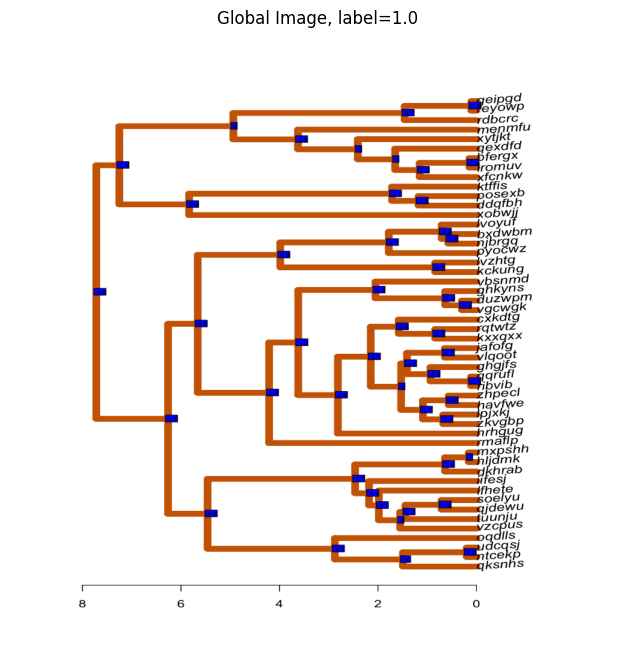

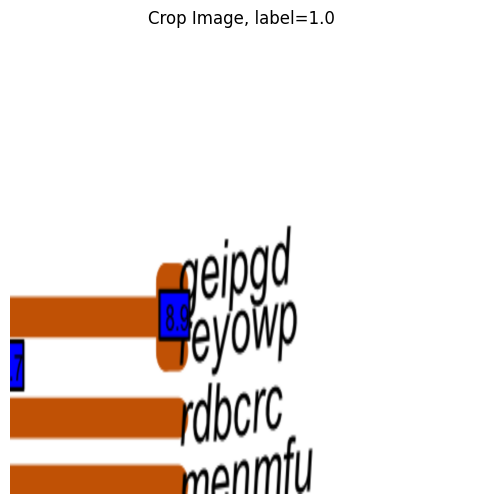

In [ ]:
global_img, crop_img, geo_feats, label = train_dataset[0]

print("=== Item 0 du train_dataset ===")
print(f"Global image : type={type(global_img)}, shape={global_img.shape}, dtype={global_img.dtype}")
print(f"Crop image   : type={type(crop_img)}, shape={crop_img.shape}, dtype={crop_img.dtype}")
print(f"Geo features : {geo_feats} type={type(global_img)}, shape={geo_feats.shape}, dtype={geo_feats.dtype})")
print(f"Label        : {label} type={type(global_img)}, shape={label.shape}, dtype={label.dtype})")

plt.figure(figsize=(8,8))
plt.imshow(global_img.permute(1,2,0).numpy()) # C,H,W -> H,W,C
plt.title(f"Global Image, label={label.item()}")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(crop_img.permute(1,2,0).numpy())
plt.title(f"Crop Image, label={label.item()}")
plt.axis("off")
plt.show()

In [ ]:
batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0, # 0 pour cpu et éviter les deadlocks
    pin_memory=False # 0 pour gpu
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0, # 0 pour cpu et éviter les deadlocks
    pin_memory=False # 0 pour gpu
)

In [ ]:
geo_feat_dim = train_dataset[0][2].shape[0]
print(f"geo_feat_dim={geo_feat_dim}")

geo_feat_dim=4


In [ ]:
model = PhyloLabelClassifier(geo_feat_dim=geo_feat_dim)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [ ]:
history = train_model(model, train_loader, val_loader, device=device, epochs=20)

Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [09:06<00:00, 42.08s/it]


Epoch 1/20 - Loss: 0.3715, Acc: 0.8144, F1: 0.7568


Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████| 14/14 [03:25<00:00, 14.64s/it]


 Val - Loss: 0.6894, Acc: 0.6095, F1: 0.0000


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [08:53<00:00, 41.03s/it]


Epoch 2/20 - Loss: 0.3308, Acc: 0.8454, F1: 0.7887


Validation:  86%|██████████████████████████████████████████████████████████████████████████████             | 12/14 [03:29<00:34, 17.31s/it]

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Courbe de Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Courbe d'Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history["train_f1"], label="Train F1")
plt.plot(history["val_f1"], label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Courbe de F1")
plt.legend()
plt.show()